In [1]:
import numpy as np
import matplotlib.pyplot as plt

# ============================
# Paramètres globaux 2D
# ============================

beta = 0.5          # exposant de diffusion rapide
Lx = 1.0            # longueur du domaine en x
Ly = 1.0            # longueur du domaine en y

Nx = 40             # nb de volumes en x
Ny = 40             # nb de volumes en y
dx = Lx / Nx
dy = Ly / Ny

T = 0.1             # temps final
dt = 2e-4           # pas de temps
M = int(T / dt)     # nb de pas de temps

# Grille : centres de mailles
x = (np.arange(Nx) + 0.5) * dx
y = (np.arange(Ny) + 0.5) * dy
X, Y = np.meshgrid(x, y, indexing='ij')

# valeurs d'alpha pour les entropies
alphas = [0.5, 1.0, 2.0, 6.0]

times = np.arange(M + 1) * dt


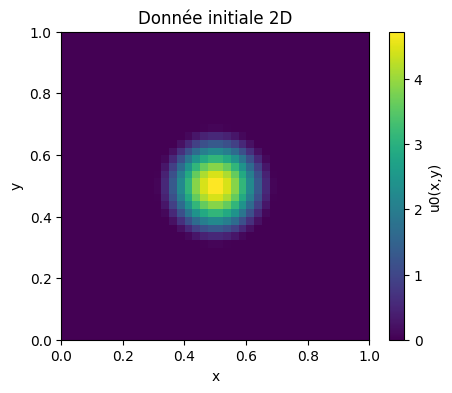

In [2]:
# ============================
# Donnée initiale 2D
# ============================

def initial_data_2d(X, Y):
    """
    Exemple : "tumeur" au centre, type bump polynomial compact supporté
    u0(x,y) = C * max(R^2 - (x-0.5)^2 - (y-0.5)^2, 0)^2
    """
    R = 0.2     # rayon
    C = 3000.0  # amplitude (comme en 1D mais adaptée)
    r2 = (X - 0.5)**2 + (Y - 0.5)**2
    inside = np.maximum(R**2 - r2, 0.0)
    return C * inside**2

u = initial_data_2d(X, Y)

# Visualisation de u0
plt.figure(figsize=(5, 4))
plt.imshow(u.T, origin='lower', extent=[0, Lx, 0, Ly], aspect='equal')
plt.colorbar(label="u0(x,y)")
plt.title("Donnée initiale 2D")
plt.xlabel("x")
plt.ylabel("y")
plt.show()


In [3]:
# ============================
# Outils : Laplacien 2D (Neumann) et un pas de temps
# ============================

def laplacian_neumann(phi, dx, dy):
    """
    Laplacien discret 2D avec conditions de Neumann homogènes (flux nul) :
    on "prolonge" phi par réflexion aux bords.
    phi : array (Nx, Ny)
    """
    Nx, Ny = phi.shape
    # padding avec réflexion
    phi_ext = np.zeros((Nx + 2, Ny + 2))
    phi_ext[1:-1, 1:-1] = phi

    # bords en x
    phi_ext[0, 1:-1]  = phi[0, :]      # i = -1 -> reflété de 0
    phi_ext[-1, 1:-1] = phi[-1, :]     # i = Nx -> reflété de Nx-1

    # bords en y
    phi_ext[1:-1, 0]  = phi[:, 0]      # j = -1
    phi_ext[1:-1, -1] = phi[:, -1]     # j = Ny

    # coins
    phi_ext[0, 0]      = phi[0, 0]
    phi_ext[0, -1]     = phi[0, -1]
    phi_ext[-1, 0]     = phi[-1, 0]
    phi_ext[-1, -1]    = phi[-1, -1]

    # Laplacien
    lap = (
        (phi_ext[2:, 1:-1] - 2*phi_ext[1:-1, 1:-1] + phi_ext[0:-2, 1:-1]) / dx**2 +
        (phi_ext[1:-1, 2:] - 2*phi_ext[1:-1, 1:-1] + phi_ext[1:-1, 0:-2]) / dy**2
    )
    return lap


def one_time_step_implicit_picard(u_old, beta, dx, dy, dt, n_iter=10):
    """
    Un pas de temps "implicite" pour u_t = Δ(u^beta),
    résolu par itération de point fixe (Picard) :
        u^{n+1} = u^n + dt * Δ( (u^{n+1})^beta )
    On approxime u^{n+1} via :
        u^{(m+1)} = u^n + dt * Δ( (u^{(m)})^beta )
    """
    u_new = u_old.copy()
    for _ in range(n_iter):
        # on impose u >= 0 pour garder un sens physique
        u_new = np.maximum(u_new, 0.0)
        phi = np.maximum(u_new, 1e-14)**beta
        lap_phi = laplacian_neumann(phi, dx, dy)
        u_new = u_old + dt * lap_phi
    return np.maximum(u_new, 0.0)


In [4]:
# ============================
# Entropies discrètes E_d^α et F_d^α (2D)
# ============================

def E_d(u, alpha, dx, dy):
    """
    E_d^α[u] = 1/(α+1) * ( ∑ m(K) u_K^{α+1} - (∑ m(K) u_K)^{α+1} )
    En 2D uniforme, m(K) = dx * dy.
    """
    cell_area = dx * dy
    mass = np.sum(u) * cell_area
    s1 = np.sum(u**(alpha + 1)) * cell_area
    return (s1 - mass**(alpha + 1)) / (alpha + 1)


def F_d(u, alpha, dx, dy):
    """
    F_d^α[u] = 1/2 * | u^{α/2} |_{1,2,h}^2
    où |v|_{1,2,h}^2 ≈ ∑ dx dy [ (∂_x v)^2 + (∂_y v)^2 ] avec différences finies.
    """
    cell_area = dx * dy
    v = np.maximum(u, 0.0)**(alpha / 2.0)

    # dérivées en x : v[i+1,j] - v[i,j]
    dvx = (v[1:, :] - v[:-1, :]) / dx
    # dérivées en y : v[i,j+1] - v[i,j]
    dvy = (v[:, 1:] - v[:, :-1]) / dy

    seminorm_sq = (
        np.sum(dvx**2) * cell_area +
        np.sum(dvy**2) * cell_area
    )
    return 0.5 * seminorm_sq


In [5]:
# ============================
# Boucle en temps + stockage des entropies
# ============================

# Historiques E_d et F_d pour chaque alpha
E_hist = {a: np.zeros(M + 1) for a in alphas}
F_hist = {a: np.zeros(M + 1) for a in alphas}

# valeurs initiales
for a in alphas:
    E_hist[a][0] = E_d(u, a, dx, dy)
    F_hist[a][0] = F_d(u, a, dx, dy)

# temps auxquels on sauvegarde des "snapshots" de u
snapshot_times = [0.0, 0.01, 0.05, 0.1]
snapshot_indices = [int(t / dt) for t in snapshot_times]
snapshots = {}

for k in range(1, M + 1):
    u = one_time_step_implicit_picard(u, beta, dx, dy, dt, n_iter=10)

    # entropies
    for a in alphas:
        E_hist[a][k] = E_d(u, a, dx, dy)
        F_hist[a][k] = F_d(u, a, dx, dy)

    # snapshots de la solution
    if k in snapshot_indices:
        snapshots[k] = u.copy()


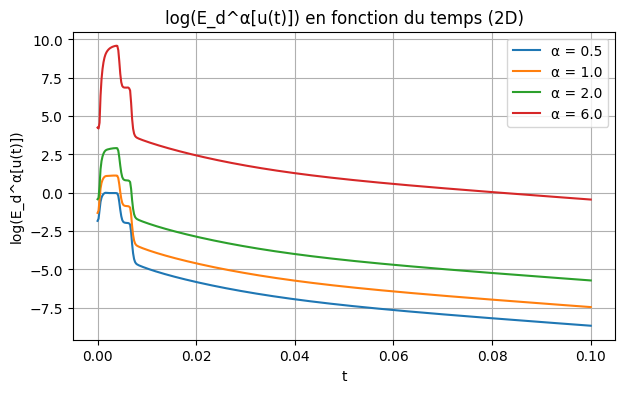

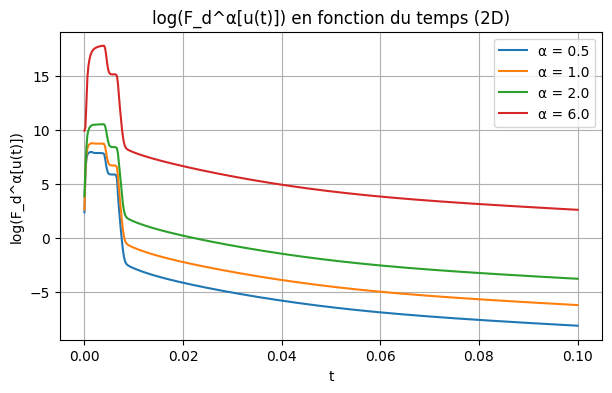

In [6]:
# ============================
# Graphes log(E_d^α) et log(F_d^α)
# ============================

# log(E_d)
plt.figure(figsize=(7, 4))
for a in alphas:
    y = np.maximum(E_hist[a], 1e-300)
    plt.plot(times, np.log(y), label=f"α = {a}")
plt.xlabel("t")
plt.ylabel("log(E_d^α[u(t)])")
plt.title("log(E_d^α[u(t)]) en fonction du temps (2D)")
plt.legend()
plt.grid(True)
plt.show()

# log(F_d)
plt.figure(figsize=(7, 4))
for a in alphas:
    y = np.maximum(F_hist[a], 1e-300)
    plt.plot(times, np.log(y), label=f"α = {a}")
plt.xlabel("t")
plt.ylabel("log(F_d^α[u(t)])")
plt.title("log(F_d^α[u(t)]) en fonction du temps (2D)")
plt.legend()
plt.grid(True)
plt.show()


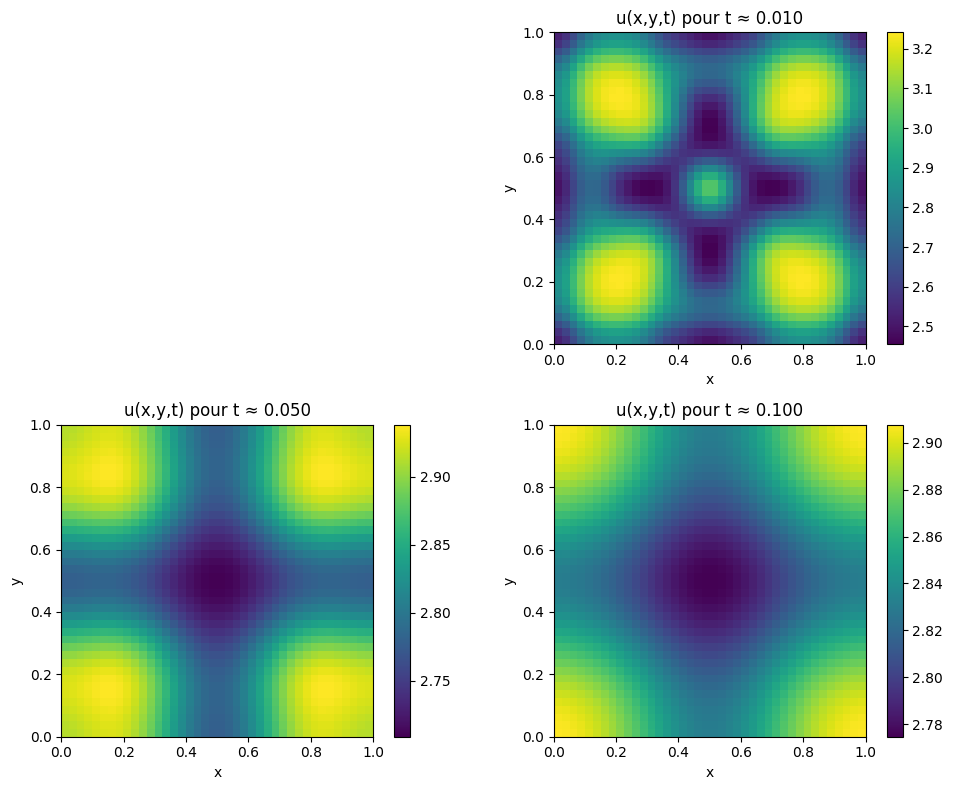

In [ ]:
# ============================
# Snapshots de u(x,y,t)
# ============================

plt.figure(figsize=(10, 8))

for i, (t_snap, k_snap) in enumerate(zip(snapshot_times, snapshot_indices), start=1):
    u_snap = snapshots.get(k_snap, None)
    if u_snap is None:
        continue
    plt.subplot(2, 2, i)
    plt.imshow(u_snap.T, origin='lower', extent=[0, Lx, 0, Ly], aspect='equal')
    plt.colorbar()
    plt.title(f"u(x,y,t) pour t ≈ {t_snap:.3f}")
    plt.xlabel("x")
    plt.ylabel("y")

plt.tight_layout()
plt.show()
# ????
# La solution doit être radiale par rapport au centre